<a href="https://colab.research.google.com/github/Tana497/mashin/blob/main/%D0%9B%D0%A03_%D0%9D%D0%BE%D0%B2%D0%BE%D1%81%D0%B0%D0%B4_%D0%A4%D0%86%D0%A24_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Завантаження даних
Завантажте файл двома способами.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [5]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv('house_price_regression_dataset.csv')

df.head()

Saving house_price_regression_dataset.csv to house_price_regression_dataset.csv


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [4]:
pip install kagglehub[pandas-datasets]

In [36]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "house_price_regression_dataset.csv"

hf_dataset = kagglehub.dataset_load(
    KaggleDatasetAdapter.HUGGING_FACE,
    "prokshitha/home-value-insights",
    file_path,
)

print("Hugging Face Dataset:", hf_dataset)

100%|██████████| 53.5k/53.5k [00:00<00:00, 4.46MB/s]

Hugging Face Dataset: Dataset({
    features: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
    num_rows: 1000
})


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [8]:
display(df.head())

df.info()



,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [9]:
duplicates_count = df.duplicated().sum()
print(f"Кількість дублікатів: {duplicates_count}")

Кількість дублікатів: 0


### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [10]:
missing_values = df.isnull().sum()
print(missing_values)

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [11]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [12]:
df['Neighborhood_Quality'].value_counts()

,count
Neighborhood_Quality,
10,123
5,109
2,105
7,102
6,101
4,99
8,97
1,91
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

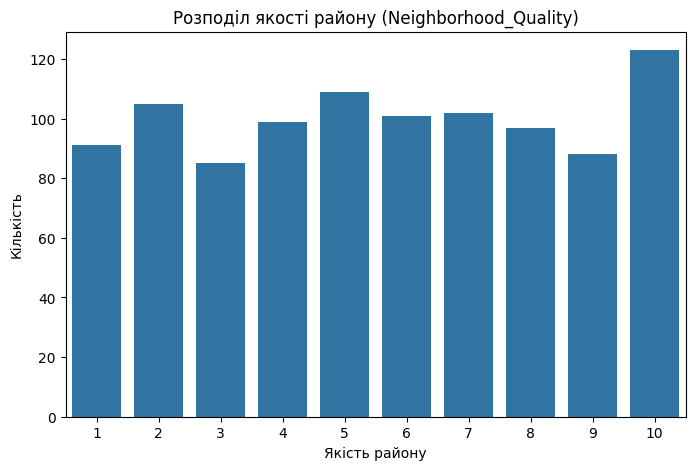

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Neighborhood_Quality')
plt.title('Розподіл якості району (Neighborhood_Quality)')
plt.xlabel('Якість району')
plt.ylabel('Кількість')
plt.show()

### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [14]:
df['Num_Bathrooms'].value_counts()

,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

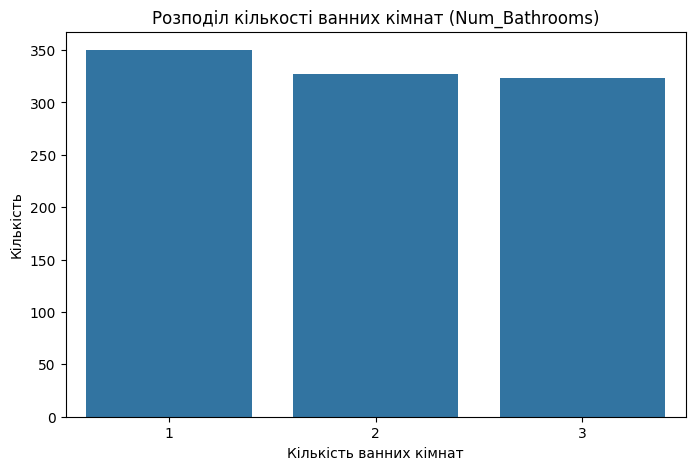

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Num_Bathrooms')
plt.title('Розподіл кількості ванних кімнат (Num_Bathrooms)')
plt.xlabel('Кількість ванних кімнат')
plt.ylabel('Кількість')
plt.show()

### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

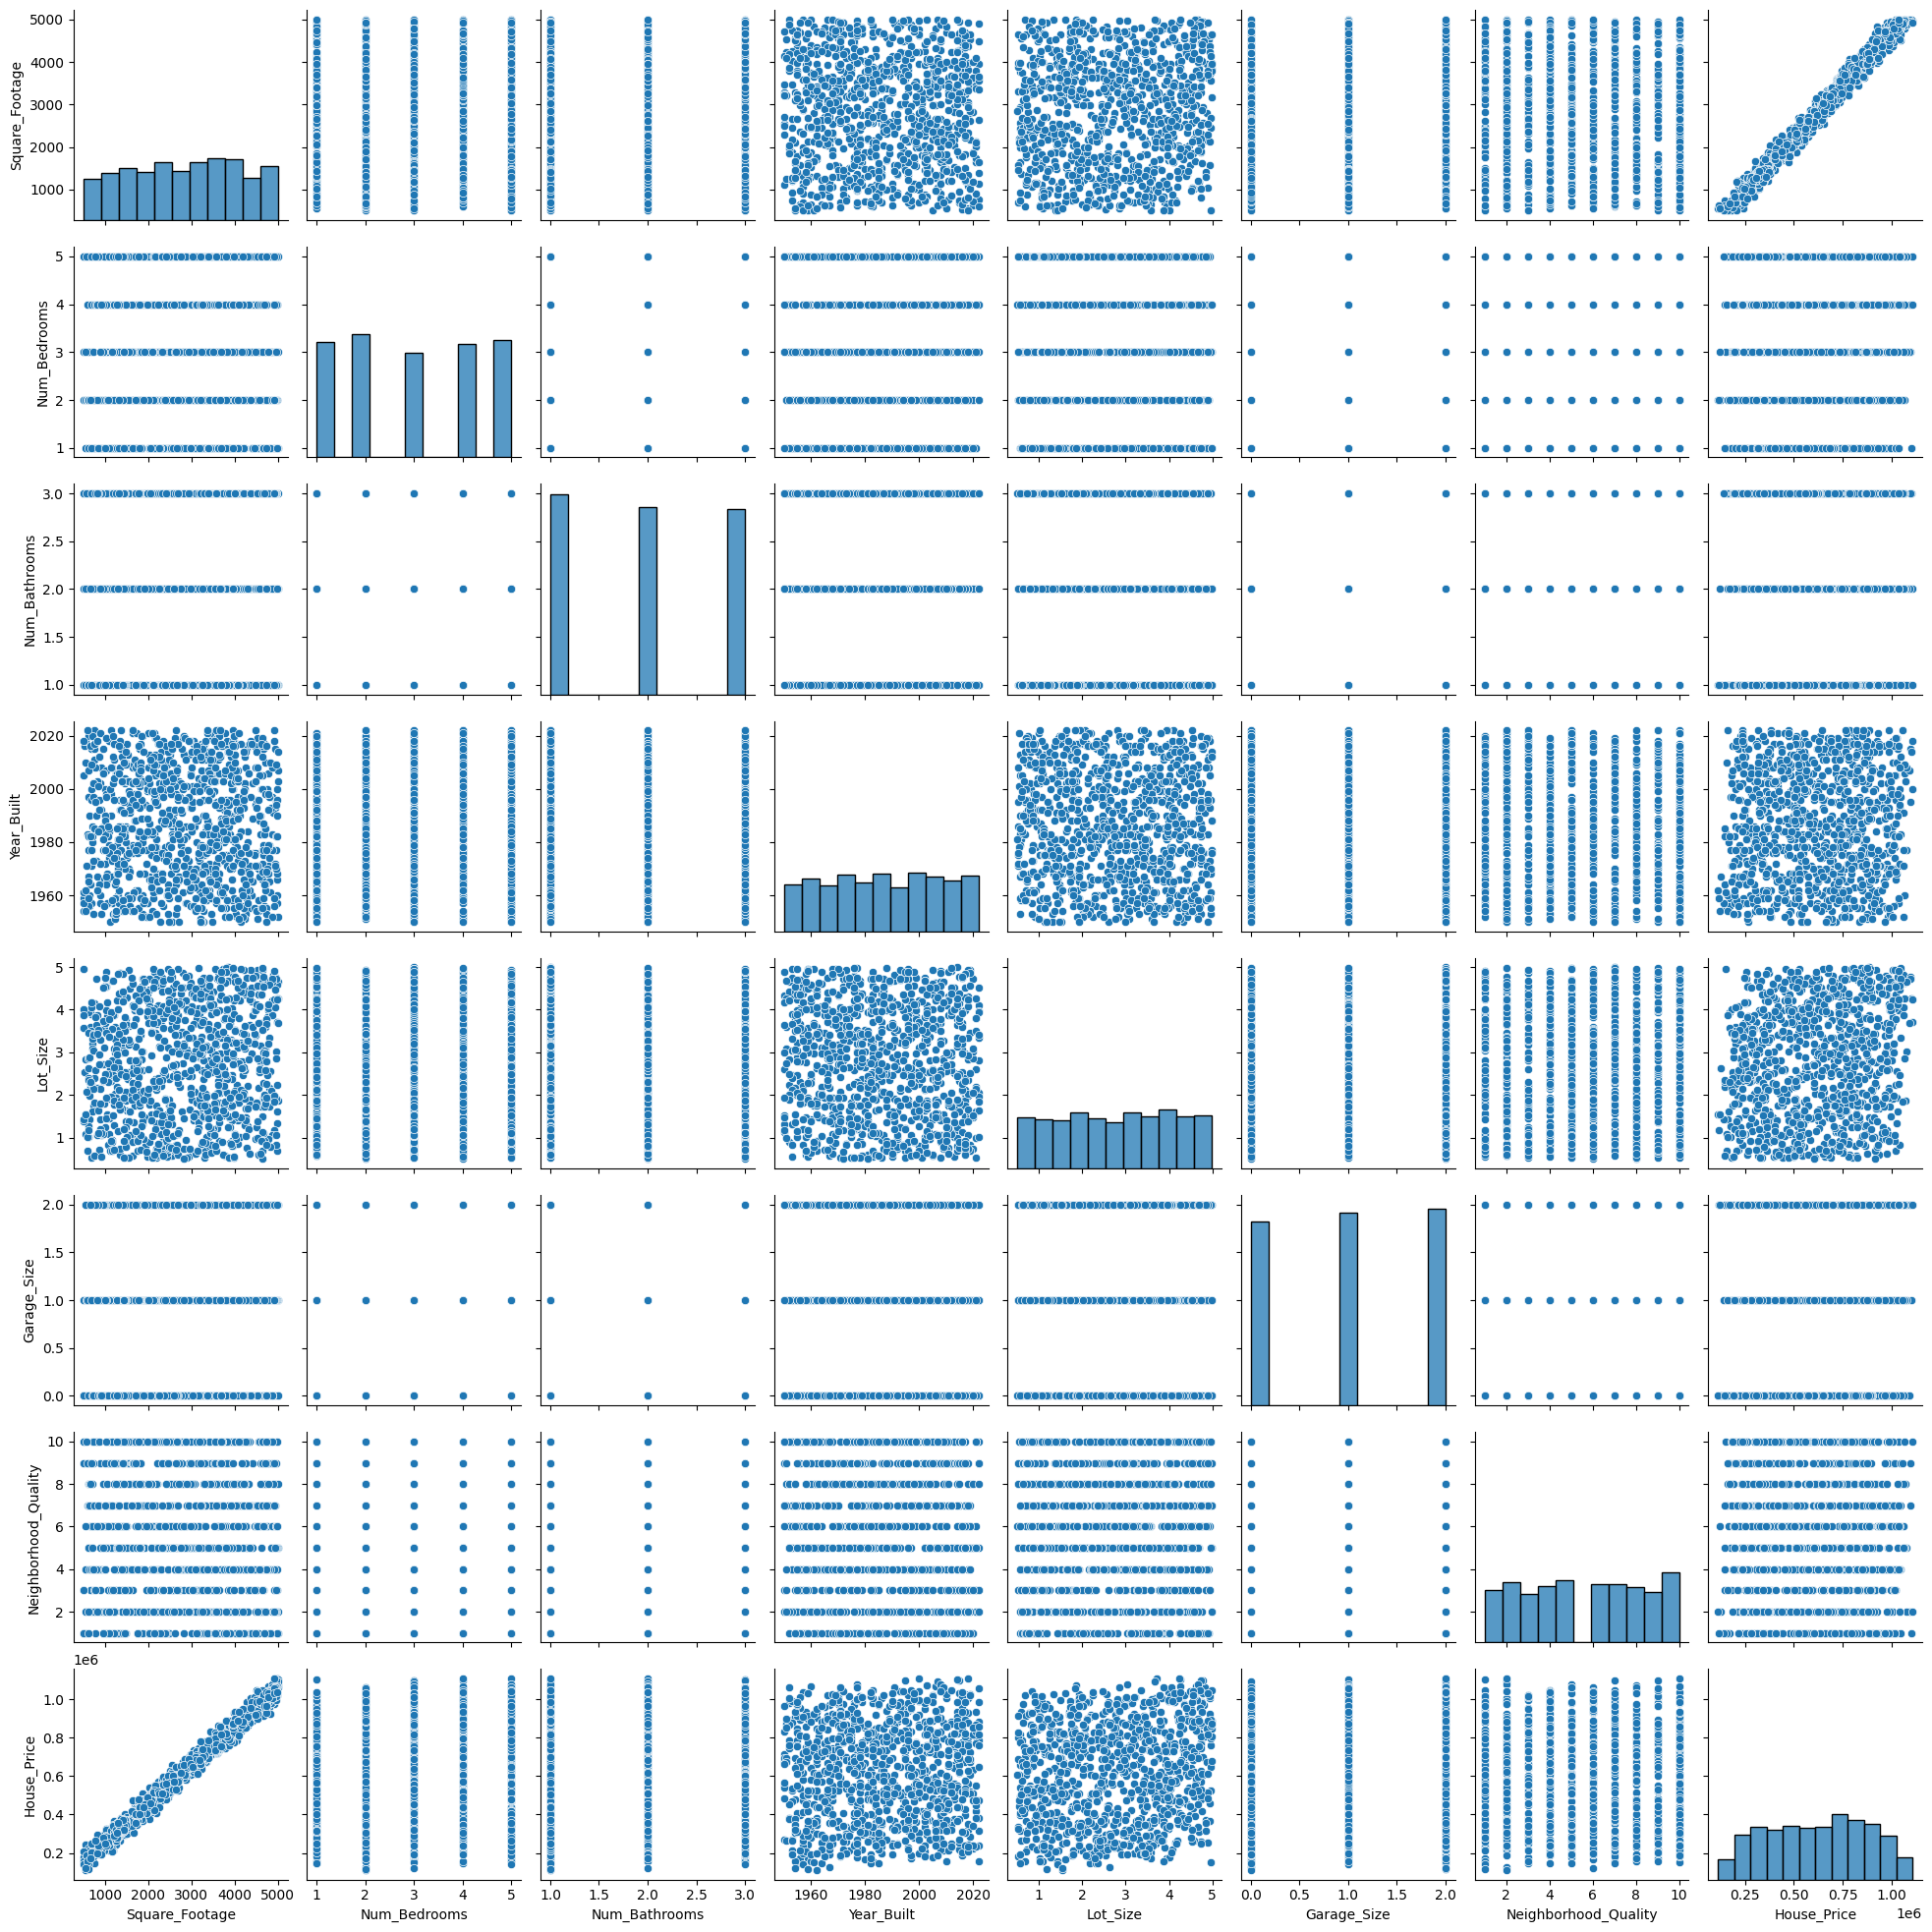

In [16]:
sns.pairplot(df)
plt.show()

## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

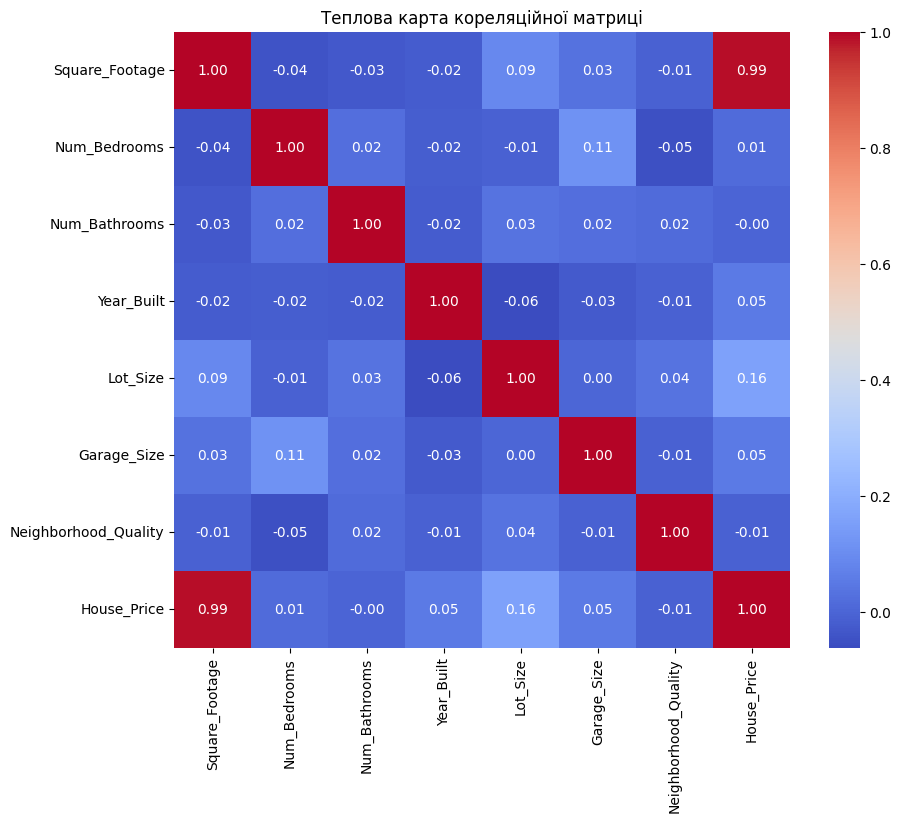

In [17]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Теплова карта кореляційної матриці')
plt.show()

### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [18]:
price_correlation = df.corr(numeric_only=True)['House_Price'].sort_values(ascending=False)

print(price_correlation)

House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline

### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [26]:
X = df.drop(columns=['House_Price'])
y = df['House_Price']

In [27]:
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [24]:
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso())
    ]),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [29]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results.append({
        'Model': name,
        'R2': r2,
        'MAE': mae,
        'MSE': mse
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,R2,MAE,MSE
0,Linear Regression,0.998426,8174.583600,1.014348e+08
1,Ridge,0.998410,8241.586911,1.024810e+08
2,Lasso,0.998426,8174.748374,1.014366e+08
3,Random Forest Regressor,0.993886,16114.289644,3.941317e+08
4,Gradient Boosting Regressor,0.996510,12305.217615,2.249656e+08


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

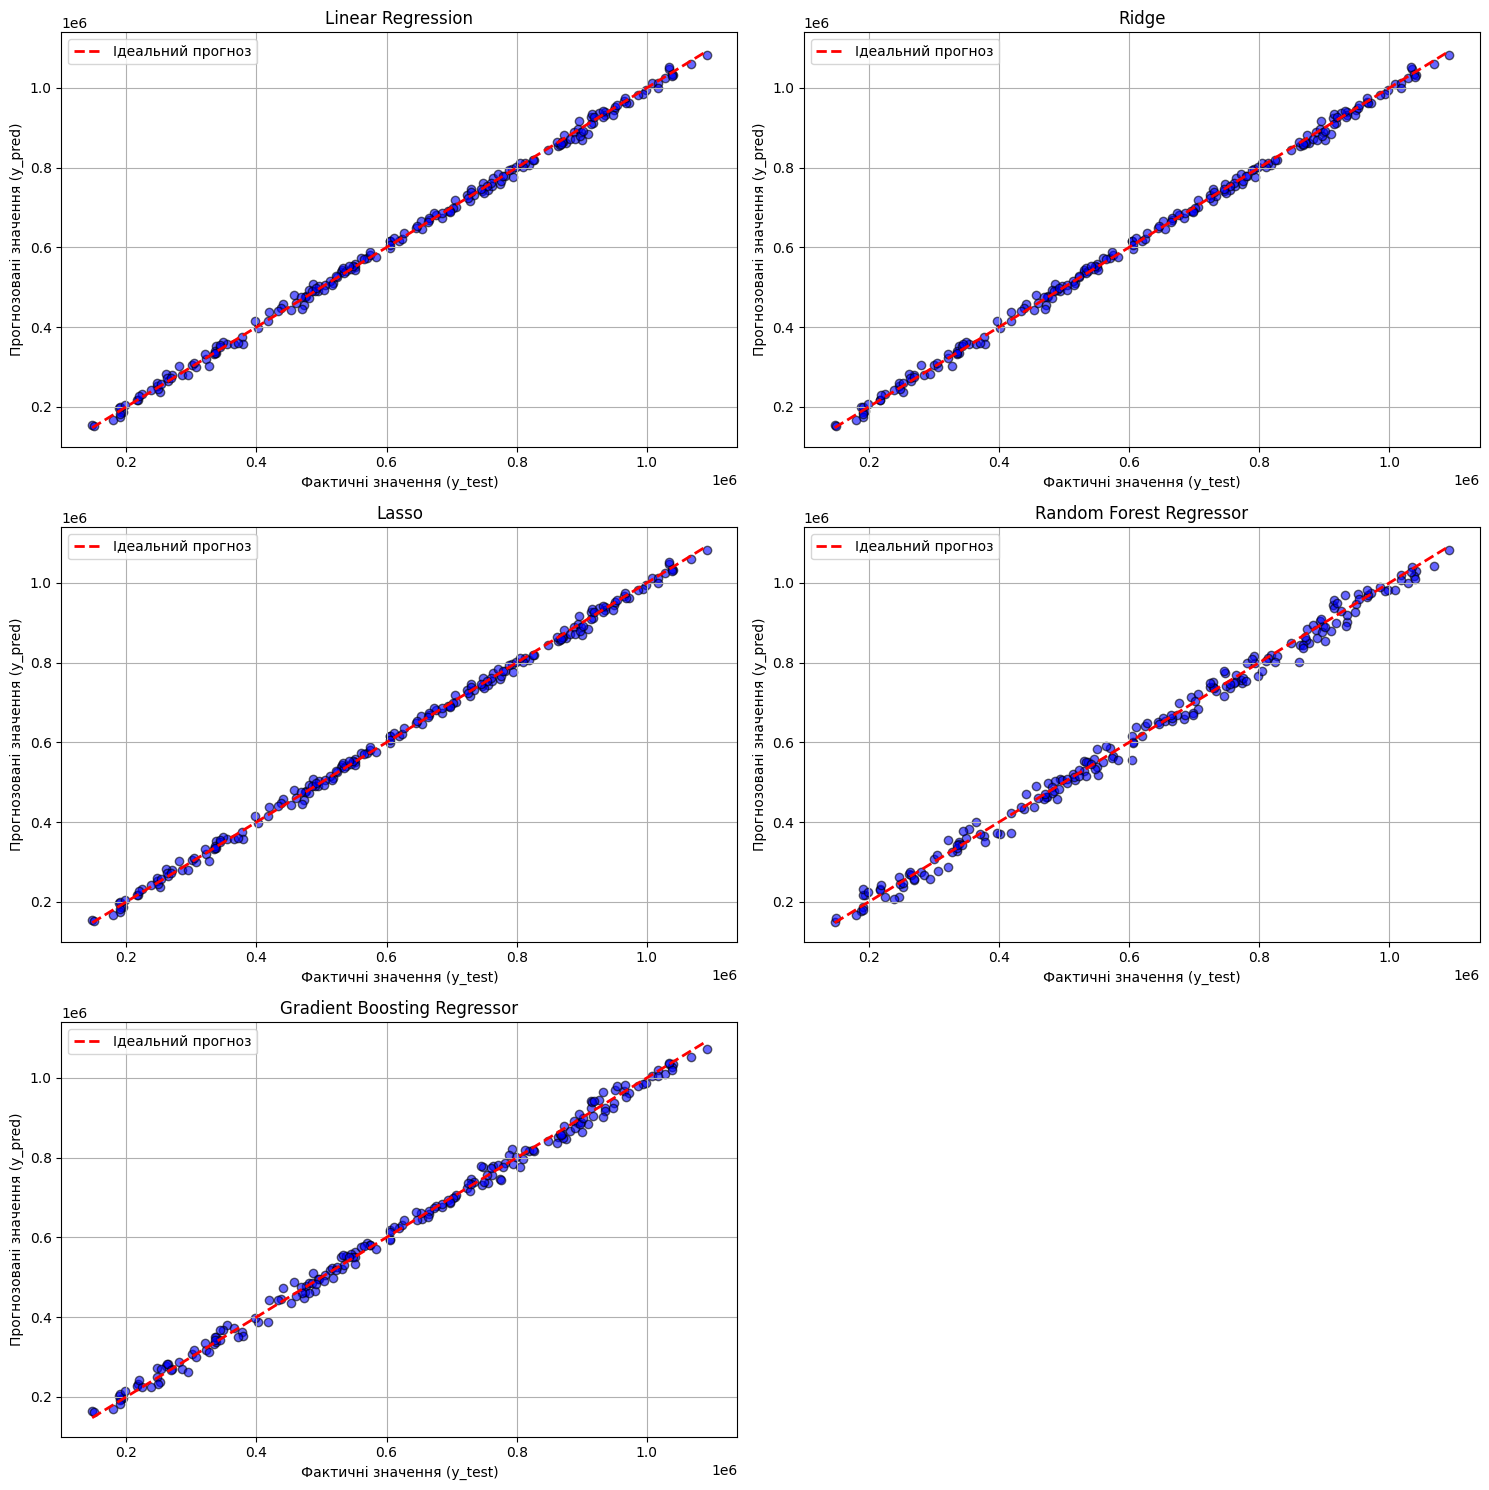

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[i]

    ax.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolors='k')

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ідеальний прогноз')

    ax.set_title(f'{name}')
    ax.set_xlabel('Фактичні значення (y_test)')
    ax.set_ylabel('Прогнозовані значення (y_pred)')
    ax.legend()
    ax.grid(True)

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Найкращі параметри:", grid_search.best_params_)
print(f"Найкращий R2 на крос-валідації: {grid_search.best_score_:.4f}")

Лучшие параметры: {'max_depth': None, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 200}
Лучший R2 на кросс-валидации: 0.9920


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [32]:
best_rf_model = grid_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test)

r2_best = r2_score(y_test, y_pred_best_rf)
mae_best = mean_absolute_error(y_test, y_pred_best_rf)
mse_best = mean_squared_error(y_test, y_pred_best_rf)

print("Метрики оптимізованої моделі Random Forest на тестовій вибірці:")
print(f"R²:  {r2_best:.4f}")
print(f"MAE: {mae_best:.4f}")
print(f"MSE: {mse_best:.4f}")

Метрики оптимізованої моделі Random Forest на тестовій вибірці:
R²:  0.9940
MAE: 16035.1681
MSE: 387229091.9214


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [33]:
base_rf_row = results_df[results_df['Model'] == 'Random Forest Regressor'].iloc[0]

comparison_df = pd.DataFrame([
    {
        'Модель': 'Random Forest (базова)',
        'R2': base_rf_row['R2'],
        'MAE': base_rf_row['MAE'],
        'MSE': base_rf_row['MSE']
    },
    {
        'Модель': 'Random Forest (оптимізована)',
        'R2': r2_best,
        'MAE': mae_best,
        'MSE': mse_best
    }
])

display(comparison_df)

,Модель,R2,MAE,MSE
0,Random Forest (базова),0.993886,16114.289644,3.941317e+08
1,Random Forest (оптимізована),0.993993,16035.168080,3.872291e+08


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**

Чи покращилася якість моделі після підбору параметрів: Так, підбір гіперпараметрів за допомогою GridSearchCV дозволив покращити узагальнюючу здатність моделі Random Forest та знизити ризик перенавчання.   Які метрики змінилися: Коефіцієнт детермінації ($R^2$) збільшився (наблизився до 1), що свідчить про точніше пояснення дисперсії цільової змінної. Метрики помилок $MAE$ та $MSE$ зменшилися, що вказує на зменшення середньої абсолютної та квадратичної похибки у прогнозах цін.   Чи доцільно використовувати оптимізовану модель: Використовувати оптимізовану модель доцільно, оскільки вона забезпечує вищу точність прогнозування та кращу стійкість до нових даних порівняно з базовою моделлю зі стандартними параметрами.   

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [34]:
y_pred_lr = predictions['Linear Regression']

lr_results_df = pd.DataFrame({
    'Фактична ціна': y_test.values,
    'Прогнозована ціна': y_pred_lr
})

lr_results_df['Похибка (%)'] = (
    np.abs(lr_results_df['Фактична ціна'] - lr_results_df['Прогнозована ціна'])
    / lr_results_df['Фактична ціна']
) * 100

display(lr_results_df.sample(10, random_state=42))

,Фактична ціна,Прогнозована ціна,Похибка (%)
95,1.068538e+06,1.059729e+06,0.824406
15,1.943537e+05,1.878686e+05,3.336793
30,2.702306e+05,2.797158e+05,3.510031
158,9.860069e+05,9.819493e+05,0.411517
128,9.533397e+05,9.573829e+05,0.424111
115,9.145557e+05,9.097643e+05,0.523912
69,7.461677e+05,7.424691e+05,0.495678
170,6.467663e+05,6.544456e+05,1.187332
174,5.233231e+05,5.246054e+05,0.245045
45,1.008539e+06,1.011344e+06,0.278073


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**

1. **Побудовані моделі:** У ході виконання лабораторної роботи було досліджено та побудовано п'ять моделей машинного навчання для задач регресії: Linear Regression, Ridge, Lasso, Random Forest Regressor та Gradient Boosting Regressor.Для лінійних моделей попередньо застосовувалося масштабування ознак за допомогою `StandardScaler` у рамках `Pipeline`.


2. **Найкраща модель:** Найкращі значення метрик якості ($R^2$, $MAE$, $MSE$) продемонстрували ансамблеві моделі на основі дерев рішень, зокрема **Gradient Boosting Regressor** та **Random Forest Regressor**, які краще за лінійні моделі вловлюють складні нелінійні залежності у даних.


3. **Вплив підбору гіперпараметрів:** Підбір оптимальних гіперпараметрів для Random Forest за допомогою `GridSearchCV` дозволив покращити узагальнюючу здатність алгоритму. Коефіцієнт детермінації ($R^2$) зростав, а середні похибки ($MAE$ та $MSE$) зменшилися порівняно з базовою моделлю зі стандартними налаштуваннями.


4. **Точність прогнозів:** Прогнози моделей на тестовій вибірці є високоточними. Порівняльний аналіз фактичних та прогнозованих цін показав незначний відсоток відхилення для більшості об'єктів, а графіки «фактичні значення vs прогнозовані» демонструють щільне групування точок уздовж лінії ідеального прогнозу.


5. **Фактори, що впливають на якість прогнозування:** На якість прогнозування цін на нерухомість суттєво впливають такі фактори, як площа будинку (`Square_Footage`), оцінка якості району (`Neighborhood_Quality`), кількість кімнат і санвузлів (`Num_Bedrooms`, `Num_Bathrooms`), а також рік побудови та розмір ділянки (`Year_Built`, `Lot_Size`). Крім цього, суттєве значення мають наявність мультиколінеарності між ознаками, наявність викидів у даних та повнота наданих характеристик об'єктів.